In [ ]:
#Upload Excel File

from google.colab import files
uploaded = files.upload()

Saving city_day.csv to city_day (2).csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
df = pd.read_csv("city_day.csv")

df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,1/1/2015,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,1/1/2015,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,1/1/2015,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,1/1/2015,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,1/1/2015,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.columns

Index(['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'], dtype='object')

In [ ]:
df['City'].unique()

array(['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore'], dtype=object)

In [ ]:
pollutants = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
    'NH3', 'CO', 'SO2', 'O3',
    'Benzene', 'Toluene', 'Xylene'
]

In [ ]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,250.597695,299.442491,100.481035,75.415916,125.964079,25.065042,5.002451,49.835839,100.406740,10.070033,15.063365,4.996341,251.111382
std,144.460292,173.479906,57.774795,43.460066,72.403893,14.452019,2.889439,28.988739,57.591436,5.785282,8.619433,2.899152,144.502626
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125.700000,150.100000,50.600000,37.700000,63.100000,12.600000,2.490000,24.400000,50.600000,5.080000,7.640000,2.510000,125.400000
50%,251.000000,300.300000,100.200000,76.000000,126.200000,25.300000,5.000000,49.900000,100.700000,10.080000,15.130000,4.960000,251.200000
75%,376.200000,450.000000,151.000000,113.200000,188.900000,37.600000,7.510000,75.100000,150.400000,15.110000,22.500000,7.530000,376.400000
max,499.900000,600.000000,200.000000,150.000000,250.000000,50.000000,10.000000,100.000000,200.000000,20.000000,30.000000,10.000000,500.000000


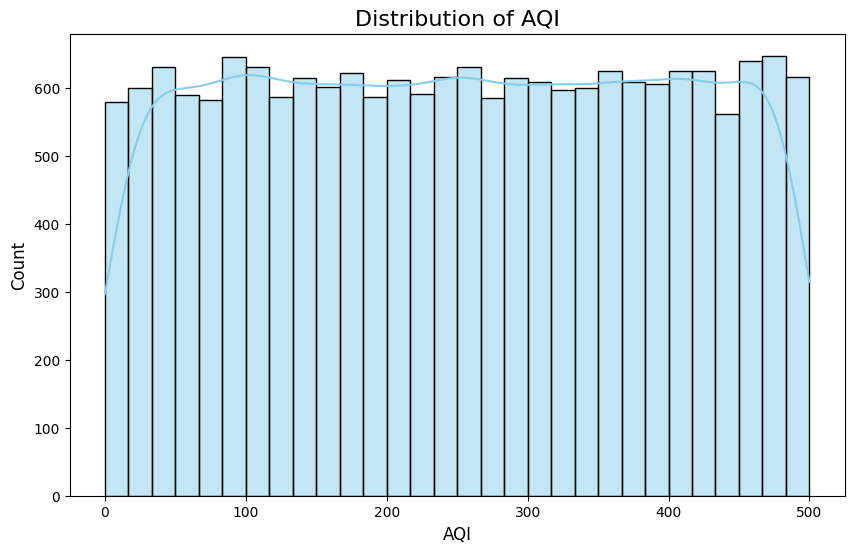

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['AQI'], bins=30, kde=True, color='skyblue')  # kde=True adds a smooth density curve
plt.title("Distribution of AQI", fontsize=16)
plt.xlabel("AQI", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

In [ ]:
# Converting df to Yearly based data

# Convert 'Datetime' column to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# This allows grouping data year-wise
df['Year'] = df['Datetime'].dt.year


# Group by BOTH Year and City
# This preserves city-wise structure instead of mixing all cities together
yearly_city_df = df.groupby(['Year', 'City']).mean(numeric_only=True).reset_index()

yearly_city_df

,Year,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
0,2015,Bangalore,252.120000,309.820274,93.970685,74.221644,128.316712,27.014795,4.864849,49.324110,97.840000,10.062849,15.792411,4.974795,245.540822
1,2015,Chennai,251.015616,309.706575,100.392329,75.354795,127.412603,25.320548,5.084274,50.660548,100.718904,9.920630,13.807014,5.050877,247.792603
2,2015,Delhi,250.915890,294.298630,99.868767,76.482740,122.369315,26.229041,4.947397,49.584658,98.499452,9.676849,16.007863,5.249836,246.632877
3,2015,Kolkata,248.486027,320.920000,104.012877,75.627945,129.784658,24.629315,5.091178,46.560822,98.942740,10.219562,14.781315,4.911671,245.955068
4,2015,Mumbai,253.589041,286.933973,97.484932,76.817808,127.335616,25.609863,5.006795,51.260000,100.123288,9.839288,15.952082,5.144849,251.168767
5,2016,Bangalore,244.113661,297.377596,99.684973,73.107377,126.635246,24.151093,5.276940,49.152186,100.366393,9.658880,15.197486,4.908743,259.028142
6,2016,Chennai,251.086066,304.536339,101.198907,75.736612,123.651639,26.050000,5.084426,49.506557,98.560383,10.013169,15.439016,4.841612,257.591257
7,2016,Delhi,231.591803,302.110109,96.558470,75.798634,123.330601,24.887705,5.004126,49.707104,100.648634,9.734290,15.099344,4.994235,254.885246
8,2016,Kolkata,252.514208,303.569399,102.514208,72.014754,121.765847,24.914208,5.077486,51.972951,102.251639,9.644672,14.953333,5.118579,241.864481
9,2016,Mumbai,244.247268,297.919399,101.020492,73.161202,130.569945,24.496995,4.995164,48.645628,100.172678,9.888115,13.988115,4.960656,237.159836


In [ ]:
year_city_aqi = df.groupby(['Year', 'City'])['AQI'].mean().reset_index()
result = year_city_aqi.loc[
    year_city_aqi.groupby('Year')['AQI'].idxmax()
]
result = result.sort_values('Year')
print(result)

    Year       City         AQI
4   2015     Mumbai  251.168767
5   2016  Bangalore  259.028142
11  2017    Chennai  259.685205
19  2018     Mumbai  264.856164
23  2019    Kolkata  265.927397
25  2020  Bangalore  260.481967
32  2021      Delhi  258.438356
35  2022  Bangalore  258.226301
42  2023      Delhi  264.894521
48  2024    Kolkata  259.620492


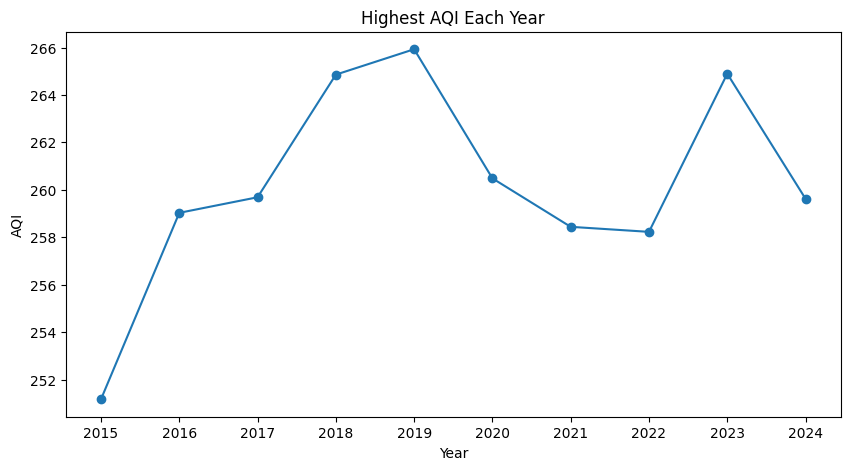

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(result['Year'], result['AQI'], marker='o')
plt.xticks(result['Year'])
plt.title("Highest AQI Each Year")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.show()

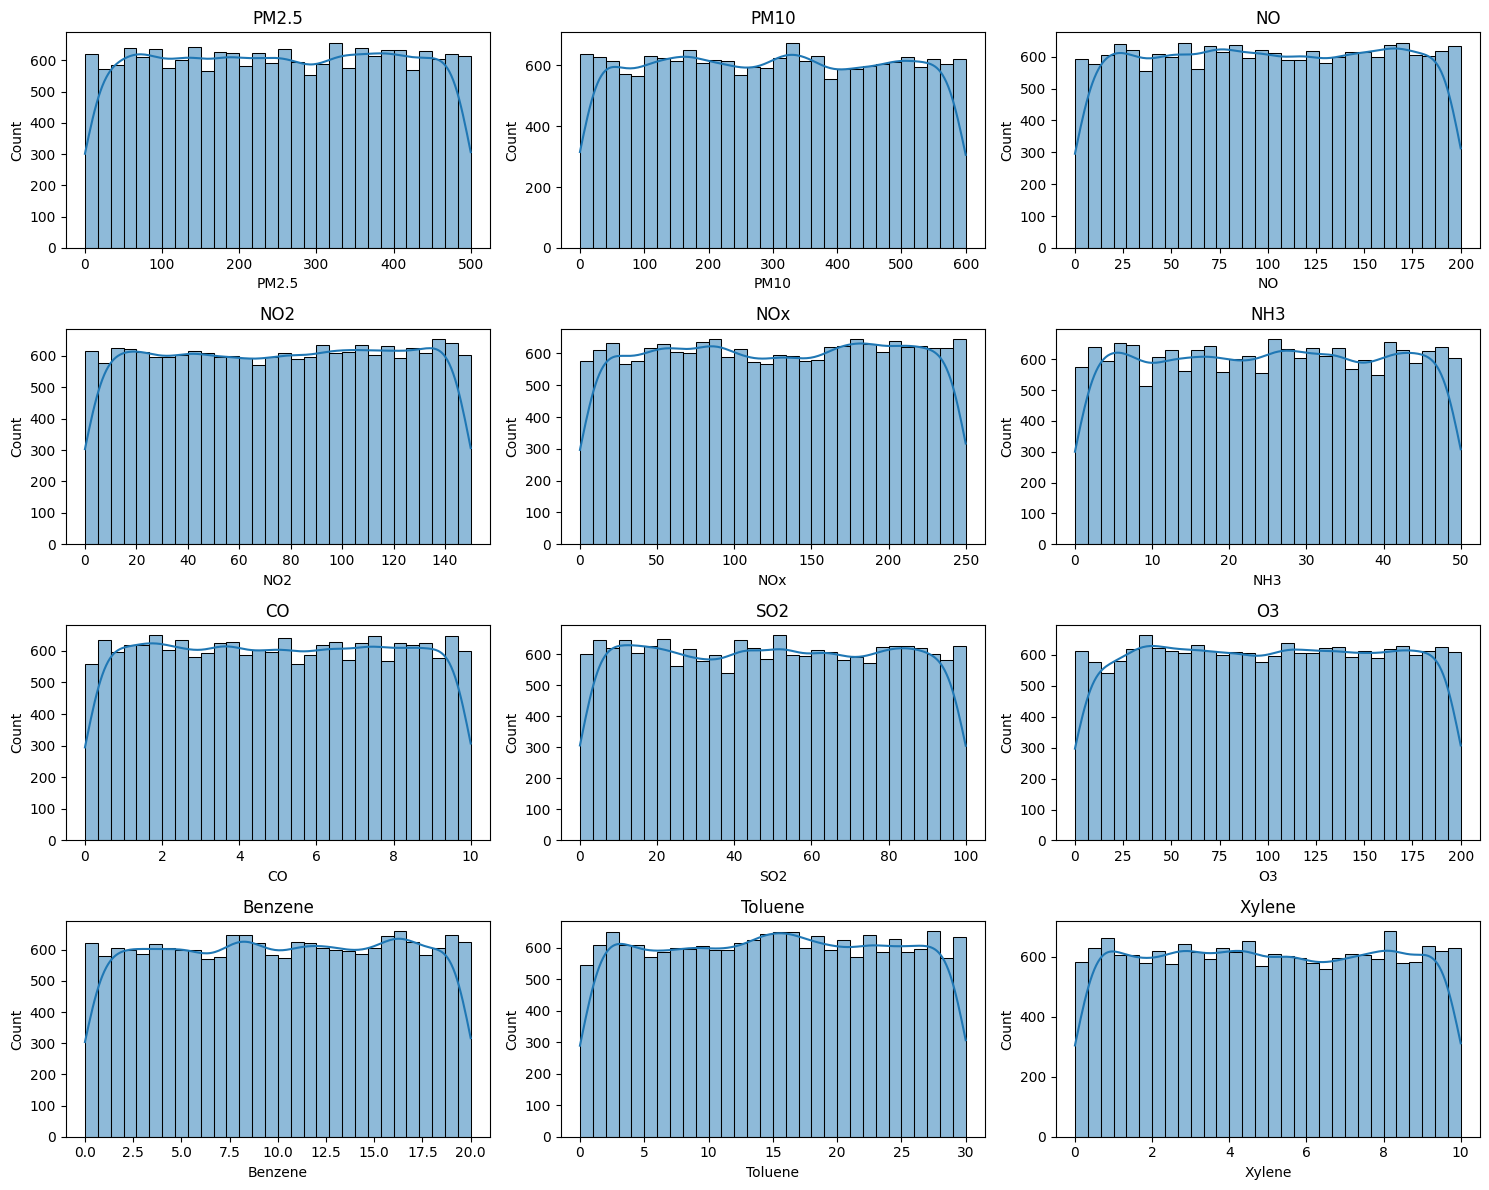

In [ ]:
# Create subplots
fig, axes = plt.subplots(4, 3, figsize=(15, 12))

axes = axes.flatten()

for i, col in enumerate(pollutants):
    sns.histplot(df[col], bins=30, ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

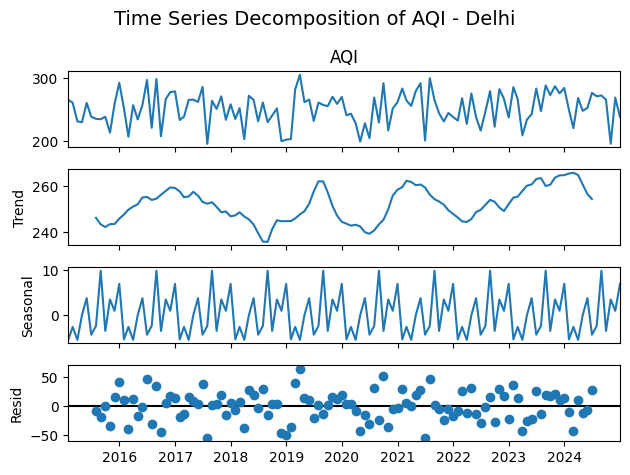

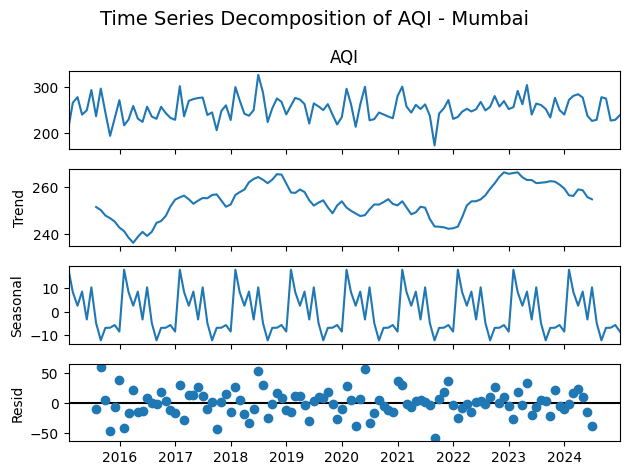

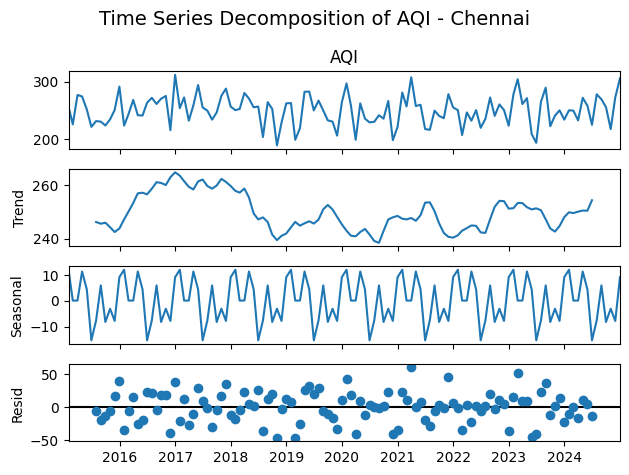

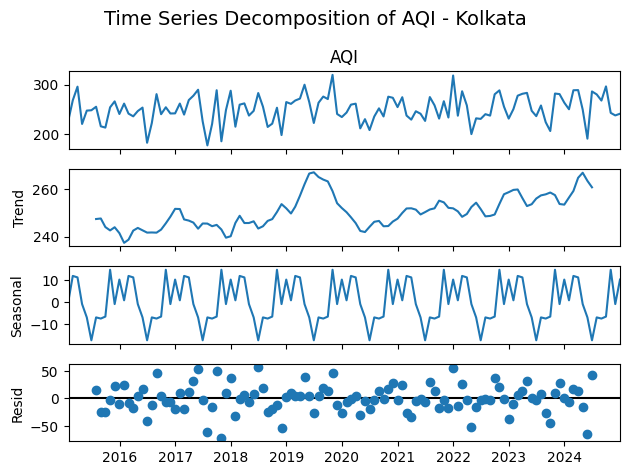

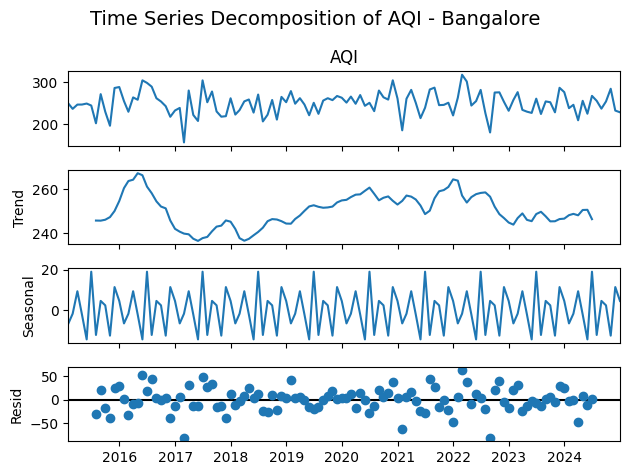

In [ ]:
# ================================
# TIME SERIES DECOMPOSITION FOR ALL CITIES
# ================================

# --------------------------------
# STEP 1: Ensure 'Datetime' is a column (not index)
# --------------------------------
# This avoids errors if the cell is run multiple times
if df.index.name == 'Datetime':
    df = df.reset_index()

# --------------------------------
# STEP 2: Convert 'Datetime' to proper datetime format
# --------------------------------
# Required because time series methods need datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# --------------------------------
# STEP 3: Sort data by date
# --------------------------------
# Ensures correct chronological order for time series analysis
df = df.sort_values('Datetime')

# --------------------------------
# STEP 4: Set 'Datetime' as index
# --------------------------------
# Required for resampling and decomposition
df.set_index('Datetime', inplace=True)

# --------------------------------
# STEP 5: Loop through each city
# --------------------------------
# We do decomposition separately because each city has its own pattern
for city in df['City'].unique():

    # --------------------------------
    # STEP 5.1: Filter data for one city
    # --------------------------------
    # Decomposition requires a single continuous time series
    df_city = df[df['City'] == city]

    # --------------------------------
    # STEP 5.2: Select AQI series
    # --------------------------------
    # We are analyzing AQI behavior over time
    aqi_series = df_city['AQI']

    # --------------------------------
    # STEP 5.3: Resample to monthly data
    # --------------------------------
    # WHY: Daily data is too dense → cluttered plots
    # Monthly average reduces noise and improves visualization
    aqi_monthly = aqi_series.resample('ME').mean()

    # --------------------------------
    # STEP 5.4: Handle missing values (if any)
    # --------------------------------
    # Decomposition requires continuous data
    aqi_monthly = aqi_monthly.interpolate()

    # --------------------------------
    # STEP 5.5: Apply decomposition
    # --------------------------------
    # model='additive' → AQI = Trend + Seasonal + Noise
    # period=12 → yearly seasonality (since monthly data)
    result = seasonal_decompose(aqi_monthly, model='additive', period=12)

    # --------------------------------
    # STEP 5.6: Plot results
    # --------------------------------
    # Shows Observed, Trend, Seasonal, Residual
    result.plot()

    # Add title for clarity (which city this plot belongs to)
    plt.suptitle(f"Time Series Decomposition of AQI - {city}", fontsize=14)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Display plot
    plt.show()

In [ ]:
# Check if 'Datetime' is already the index and reset it if it is

if df.index.name == 'Datetime':
    df = df.reset_index()

df['Datetime'] = pd.to_datetime(df['Datetime'])


# Create a function to map months → seasons

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5, 6]:
        return 'Summer'
    elif month in [7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

# Apply the function to create 'Season' column

# Extract month from Datetime and map to season
df['Season'] = df['Datetime'].dt.month.map(get_season)



# Verify that seasons are correctly assigned
print(df[['Datetime', 'Season']])


#  Convert Season to categorical
# Helps in regression (statsmodels treats it properly)
df['Season'] = df['Season'].astype('category')

        Datetime  Season
0     2015-01-01  Winter
1     2015-01-01  Winter
2     2015-01-01  Winter
3     2015-01-01  Winter
4     2015-01-01  Winter
...          ...     ...
18260 2024-12-31  Winter
18261 2024-12-31  Winter
18262 2024-12-31  Winter
18263 2024-12-31  Winter
18264 2024-12-31  Winter

[18265 rows x 2 columns]


In [ ]:
# Calculates spread/variability of AQI within each season in each city

print(df.groupby(['City','Season'])['AQI'].std())

City       Season      
Bangalore  Monsoon         148.127848
           Post-Monsoon    144.128154
           Summer          144.092299
           Winter          141.031218
Chennai    Monsoon         144.078964
           Post-Monsoon    148.484417
           Summer          145.437594
           Winter          142.477507
Delhi      Monsoon         144.669848
           Post-Monsoon    142.308557
           Summer          144.276367
           Winter          142.921785
Kolkata    Monsoon         142.210133
           Post-Monsoon    148.551879
           Summer          143.765651
           Winter          144.160043
Mumbai     Monsoon         143.819566
           Post-Monsoon    148.875410
           Summer          144.544250
           Winter          145.465200
Name: AQI, dtype: float64


/tmp/ipykernel_7276/1347015702.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['City','Season'])['AQI'].std())


In [ ]:
# Calculates spread/variability of AQI within each season in each city in from 2015 to 2024

df.groupby(['Year','City','Season'])['AQI'].std()

/tmp/ipykernel_7276/188462723.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Year','City','Season'])['AQI'].std()


Year  City       Season      
2015  Bangalore  Monsoon         141.048771
                 Post-Monsoon    147.026067
                 Summer          150.659091
                 Winter          149.480737
      Chennai    Monsoon         133.023496
                                    ...    
2024  Kolkata    Winter          136.997917
      Mumbai     Monsoon         137.491055
                 Post-Monsoon    152.982429
                 Summer          138.091910
                 Winter          149.352027
Name: AQI, Length: 200, dtype: float64

In [ ]:
# Average AQI by Season AND City from 2015 to 2024
df.groupby(['Year','City','Season'])['AQI'].mean().unstack()

/tmp/ipykernel_7276/2452927944.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Year','City','Season'])['AQI'].mean().unstack()


Season             Monsoon  Post-Monsoon      Summer      Winter
Year City                                                       
2015 Bangalore  234.519565    240.486885  246.727049  258.624444
     Chennai    228.871739    242.660656  256.290984  259.092222
     Delhi      236.143478    235.731148  240.200000  273.464444
     Kolkata    228.039130    259.824590  253.134426  245.136667
     Mumbai     259.772826    212.160656  265.585246  249.270000
2016 Bangalore  268.363043    230.454098  281.025410  239.253846
     Chennai    267.821739    246.070492  253.756557  260.112088
     Delhi      242.829348    272.267213  261.421311  246.659341
     Kolkata    247.685870    247.857377  229.695902  248.275824
     Mumbai     241.101087    238.226230  242.995902  224.636264
2017 Bangalore  253.625000    218.531148  253.291803  221.152222
     Chennai    243.466304    281.529508  260.226230  260.725556
     Delhi      236.697826    252.732787  269.914754  243.735556
     Kolkata    227.957609    216.373770  265.493443  263.541111
     Mumbai     230.232609    254.240984  274.708197  256.345556
2018 Bangalore  228.666304    237.490164  252.569672  236.383333
     Chennai    240.278261    209.075410  265.868033  255.306667
     Delhi      244.038043    226.209836  242.847541  229.151111
     Kolkata    230.264130    225.981967  257.134426  245.796667
     Mumbai     255.495652    271.885246  263.955738  270.881111
2019 Bangalore  247.361957    262.029508  245.151639  263.885556
     Chennai    250.179348    218.908197  258.534426  243.494444
     Delhi      258.117391    264.903279  266.662295  250.832222
     Kolkata    269.811957    280.647541  264.549180  253.847778
     Mumbai     257.007609    229.375410  255.248361  256.446667
2020 Bangalore  258.222826    280.924590  252.972951  259.129670
     Chennai    236.071739    233.116393  231.529508  258.906593
     Delhi      263.350000    234.077049  215.230328  248.913187
     Kolkata    240.952174    274.332787  227.968852  252.215385
     Mumbai     238.397826    234.018033  251.246721  280.762637
2021 Bangalore  271.777174    248.426230  246.534426  221.064444
     Chennai    235.584783    257.104918  261.136066  264.695556
     Delhi      270.114130    237.726230  257.339344  262.031111
     Kolkata    254.843478    250.050820  235.607377  277.936667
     Mumbai     217.221739    262.873770  255.136885  263.501111
2022 Bangalore  226.855435    264.629508  270.583607  269.203333
     Chennai    249.690217    255.742623  237.622131  228.063333
     Delhi      249.908696    275.037705  239.244262  245.340000
     Kolkata    252.218478    272.039344  230.203279  250.371111
     Mumbai     262.208696    263.749180  254.961475  244.493333
2023 Bangalore  243.476087    256.885246  237.745902  269.737778
     Chennai    259.600000    245.700000  234.012295  270.920000
     Delhi      269.688043    281.770492  242.104918  279.448889
     Kolkata    229.454348    281.204918  261.904918  263.268889
     Mumbai     249.311957    263.788525  267.876230  261.963333
2024 Bangalore  248.770652    258.739344  238.953279  237.361538
     Chennai    267.871739    244.901639  247.077869  269.009890
     Delhi      269.890217    231.716393  261.444262  236.293407
     Kolkata    281.117391    240.195082  253.440984  259.193407
     Mumbai     260.747826    227.750820  256.648361  263.975824

In [ ]:
# Average AQI in each City from 2015 to 2024

df.groupby(['Year','City'])['AQI'].mean().unstack()

City,Bangalore,Chennai,Delhi,Kolkata,Mumbai
Year,,,,,
2015,245.540822,247.792603,246.632877,245.955068,251.168767
2016,259.028142,257.591257,254.885246,241.864481,237.159836
2017,239.641644,259.685205,252.215616,247.341918,255.549589
2018,240.033425,247.322466,236.989863,242.359726,264.856164
2019,253.148767,246.097534,260.311233,265.927397,251.663288
2020,260.481967,239.742623,238.841803,244.988251,252.484153
2021,246.932877,254.899726,258.438356,253.307123,248.935616
2022,258.226301,241.335342,249.417260,247.716986,255.675616
2023,250.277260,251.515616,264.894521,257.287397,261.055890


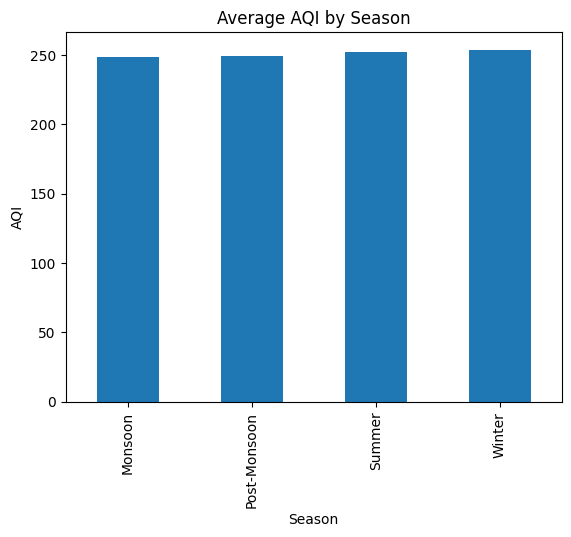

In [ ]:
season_avg.plot(kind='bar', title='Average AQI by Season')
plt.ylabel('AQI')
plt.show()

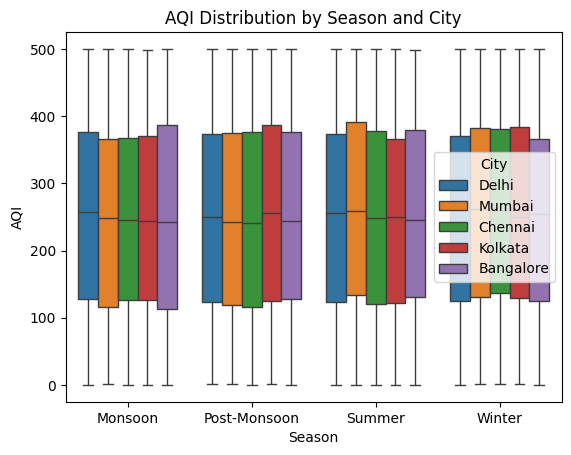

In [ ]:
sns.boxplot(x='Season', y='AQI', hue='City', data=df)
plt.title('AQI Distribution by Season and City')
plt.show()

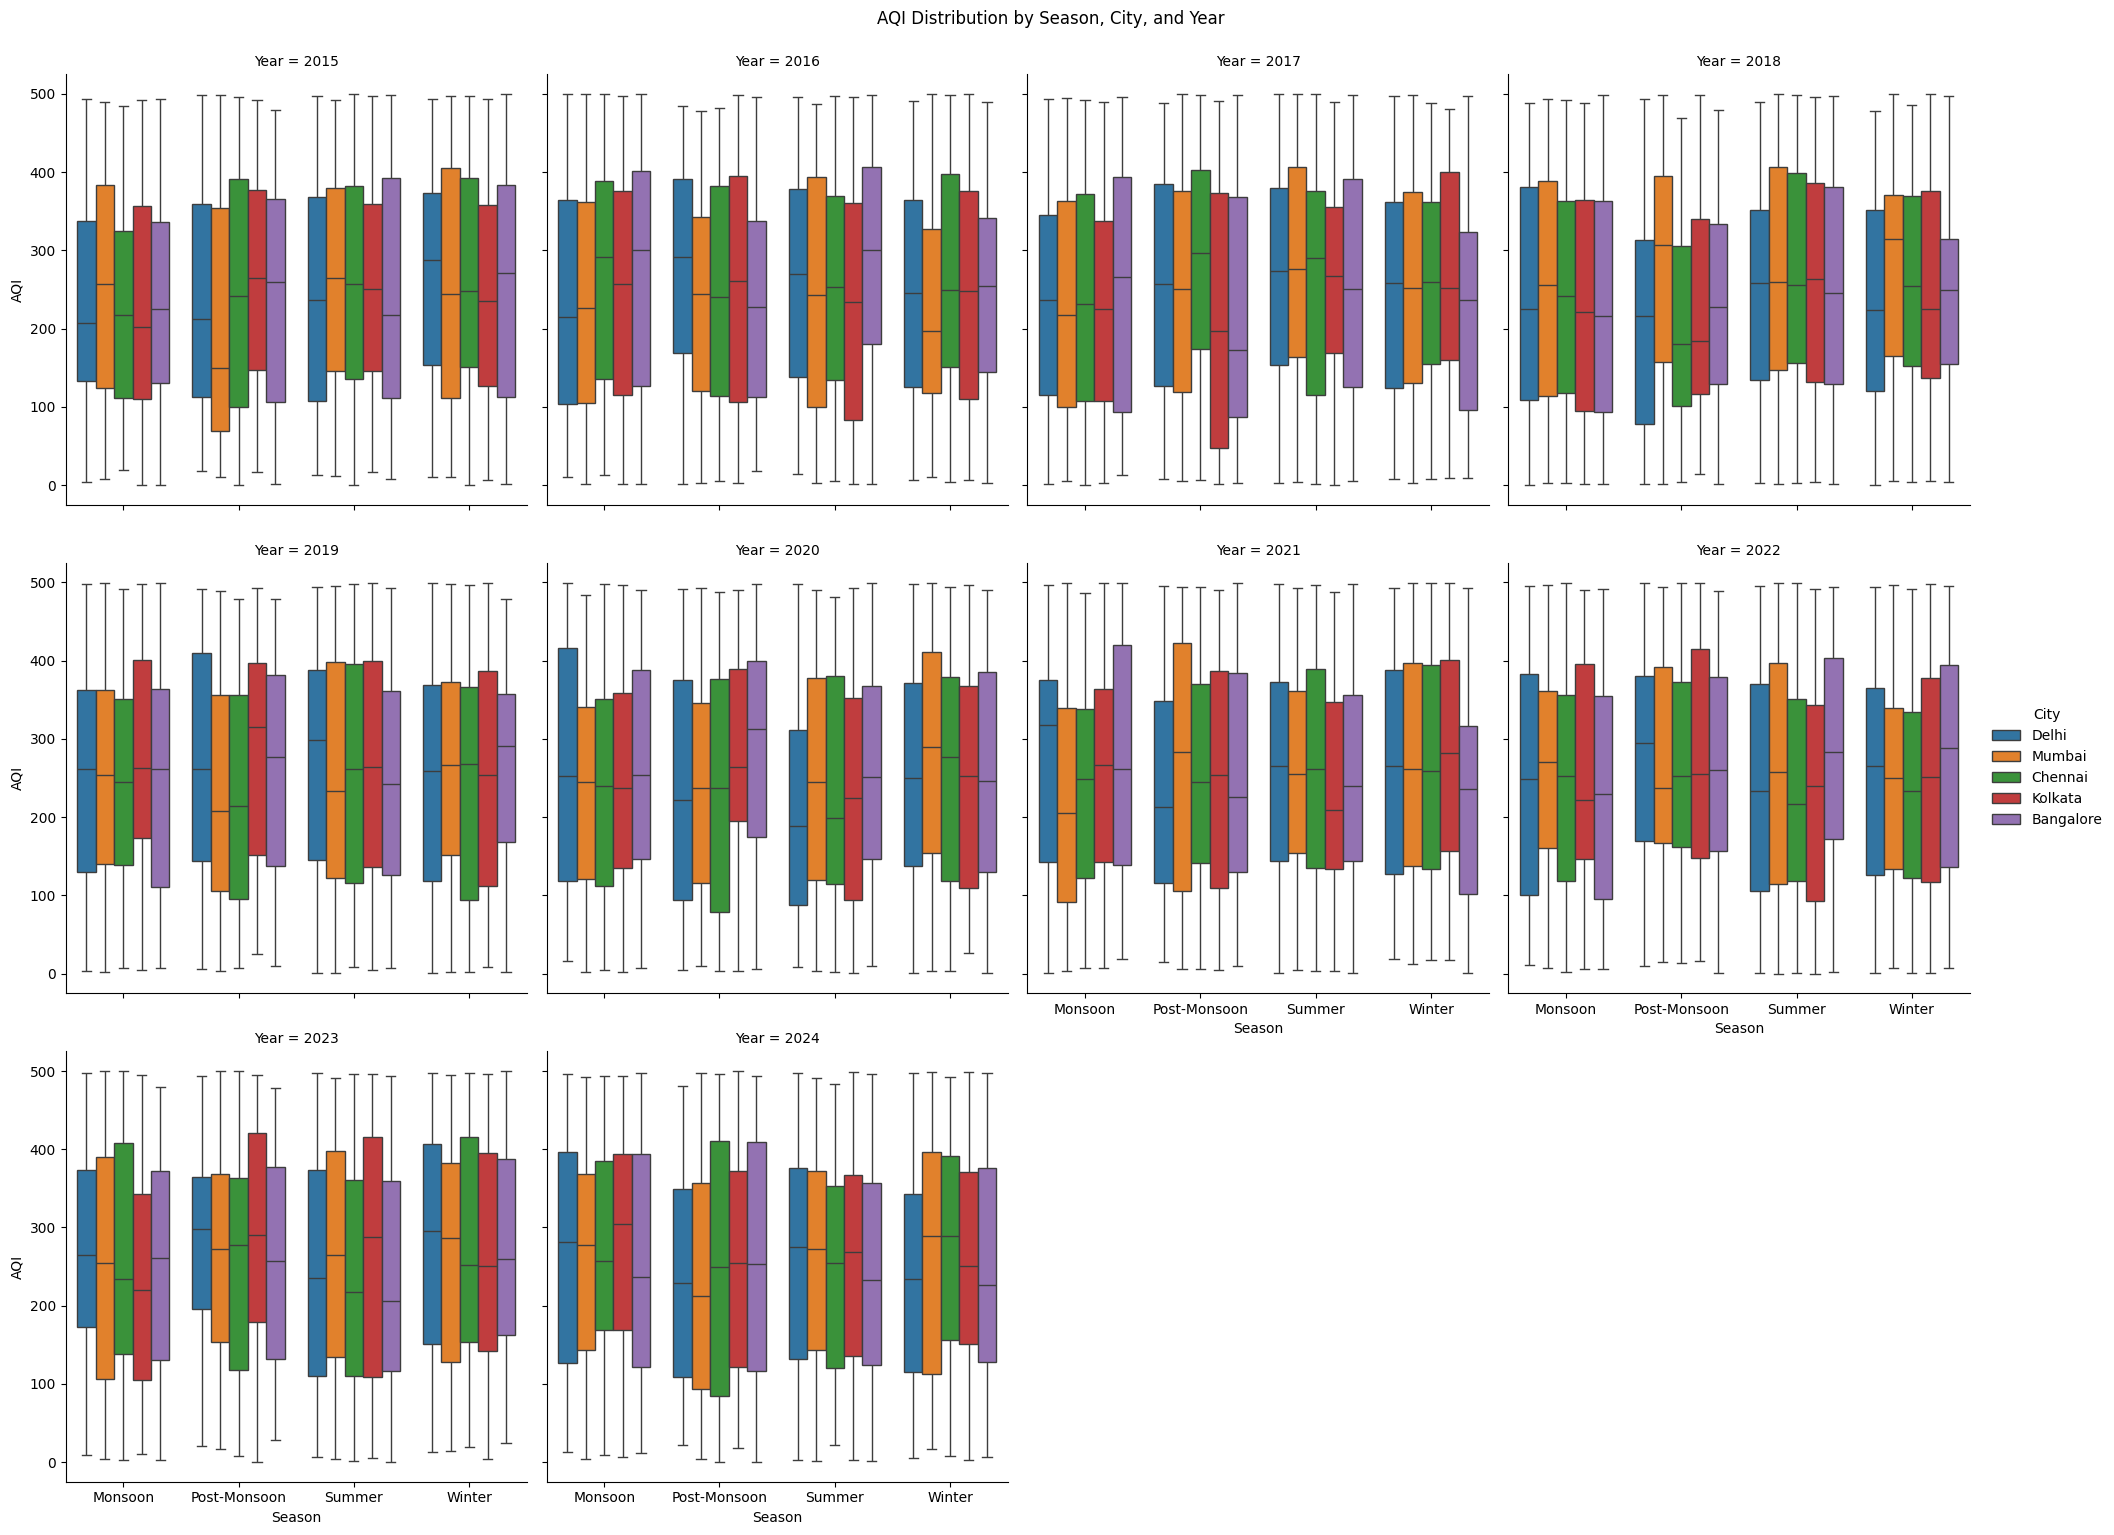

In [ ]:
# Faceting splits the plot by Year, so you can compare seasonal patterns across years
g = sns.catplot(
    x='Season',
    y='AQI',
    hue='City',
    col='Year',            # <-- THIS adds Year dimension
    data=df,
    kind='box',
    col_wrap=4             # WHY: Keeps layout readable (4 plots per row)
)

# WHY: Adds a clear title for interpretation
g.fig.suptitle('AQI Distribution by Season, City, and Year', y=1.02)

plt.show()

In [ ]:
from scipy.stats import shapiro, levene

alpha = 0.05  # significance level

for city in df['City'].unique():
    print("\n" + "="*60)
    print(f"ASSUMPTION CHECKS FOR CITY: {city}")
    print("="*60)

    city_df = df[df['City']==city]

    # -------------------------------
    # STEP 1: Normality per Season x Year group
    # -------------------------------
    print("\nNormality Check (Shapiro-Wilk) per Season x Year group:")

    normality_flag = True
    for season in city_df['Season'].unique():
        for year in city_df['Year'].unique():
            group = city_df[(city_df['Season']==season) & (city_df['Year']==year)]['AQI']
            if len(group) >= 3:  # Shapiro-Wilk requires at least 3 points
                stat, p = shapiro(group)
                result = "Normal" if p > alpha else "Not Normal"
                if p <= alpha:
                    normality_flag = False
                print(f"{season}-{year}: p={p:.4f} → {result}")

    # -------------------------------
    # STEP 2: Homogeneity of variances (Levene's test)
    # -------------------------------
    # Use AQI values grouped by Season
    groups = [city_df[city_df['Season']==s]['AQI'] for s in city_df['Season'].unique()]
    stat, p = levene(*groups)
    variance_result = "Equal variances" if p > alpha else "Unequal variances"
    print(f"\nHomogeneity of variances across Seasons: p={p:.4f} → {variance_result}")

    # -------------------------------
    # STEP 3: Recommendation
    # -------------------------------
    if not normality_flag or p <= alpha:
        print("\n=> ANOVA assumptions NOT satisfied. Consider using non-parametric alternatives (e.g., aligned-rank ANOVA).")
    else:
        print("\n=> ANOVA assumptions satisfied. You can proceed with Two-way ANOVA.")


ASSUMPTION CHECKS FOR CITY: Delhi

Normality Check (Shapiro-Wilk) per Season x Year group:
Winter-2015: p=0.0020 → Not Normal
Winter-2016: p=0.0022 → Not Normal
Winter-2017: p=0.0009 → Not Normal
Winter-2018: p=0.0054 → Not Normal
Winter-2019: p=0.0028 → Not Normal
Winter-2020: p=0.0064 → Not Normal
Winter-2021: p=0.0002 → Not Normal
Winter-2022: p=0.0017 → Not Normal
Winter-2023: p=0.0005 → Not Normal
Winter-2024: p=0.0017 → Not Normal
Summer-2015: p=0.0001 → Not Normal
Summer-2016: p=0.0003 → Not Normal
Summer-2017: p=0.0018 → Not Normal
Summer-2018: p=0.0023 → Not Normal
Summer-2019: p=0.0000 → Not Normal
Summer-2020: p=0.0000 → Not Normal
Summer-2021: p=0.0013 → Not Normal
Summer-2022: p=0.0001 → Not Normal
Summer-2023: p=0.0001 → Not Normal
Summer-2024: p=0.0001 → Not Normal
Monsoon-2015: p=0.0134 → Not Normal
Monsoon-2016: p=0.0002 → Not Normal
Monsoon-2017: p=0.0022 → Not Normal
Monsoon-2018: p=0.0004 → Not Normal
Monsoon-2019: p=0.0084 → Not Normal
Monsoon-2020: p=0.0000 → Not

In [ ]:
# ==========================================================
# NON-PARAMETRIC 2-WAY ANOVA (Scheirer-Ray-Hare)
# Tests: Season effect, Year effect, and Interaction effect
# Works when normality / equal variance is violated
# ==========================================================

from scipy.stats import rankdata, chi2

alpha = 0.05

# Function to perform Scheirer-Ray-Hare test
def srh_test(df, dv, factor1, factor2):
    """
    df      : pandas DataFrame
    dv      : dependent variable column (e.g., 'AQI')
    factor1 : first factor column (e.g., 'Season')
    factor2 : second factor column (e.g., 'Year')
    Returns : DataFrame with H-statistics and p-values
    """
    df = df.copy()
    df['rank'] = rankdata(df[dv])
    grand_mean = df['rank'].mean()

    # Sums of squares for factors
    n_total = len(df)
    ss_factor1 = sum([len(sub) * (sub['rank'].mean() - grand_mean)**2
                      for name, sub in df.groupby(factor1)])
    ss_factor2 = sum([len(sub) * (sub['rank'].mean() - grand_mean)**2
                      for name, sub in df.groupby(factor2)])
    # Interaction
    ss_inter = sum([len(sub) * (sub['rank'].mean() - grand_mean
                                - (df[df[factor1]==name1]['rank'].mean() - grand_mean)
                                - (df[df[factor2]==name2]['rank'].mean() - grand_mean))**2
                     for (name1, name2), sub in df.groupby([factor1, factor2])])

    # Total sum of squares
    ss_total = sum((df['rank'] - grand_mean)**2)

    # Residuals / error
    ss_error = ss_total - ss_factor1 - ss_factor2 - ss_inter

    # Degrees of freedom
    df1 = df[factor1].nunique() - 1
    df2 = df[factor2].nunique() - 1
    df_int = (df[factor1].nunique() - 1) * (df[factor2].nunique() - 1)

    # H-statistics
    H_factor1 = (12 / (n_total*(n_total+1))) * ss_factor1
    H_factor2 = (12 / (n_total*(n_total+1))) * ss_factor2
    H_inter = (12 / (n_total*(n_total+1))) * ss_inter

    # p-values
    p_factor1 = 1 - chi2.cdf(H_factor1, df1)
    p_factor2 = 1 - chi2.cdf(H_factor2, df2)
    p_inter = 1 - chi2.cdf(H_inter, df_int)

    results = pd.DataFrame({
        'Effect': [factor1, factor2, f'{factor1}x{factor2}'],
        'H': [H_factor1, H_factor2, H_inter],
        'df': [df1, df2, df_int],
        'p-value': [p_factor1, p_factor2, p_inter],
        'Significant': ['Yes' if p < alpha else 'No' for p in [p_factor1, p_factor2, p_inter]]
    })
    return results

# ------------------------------
# Run SRH test city-wise
# ------------------------------
for city in df['City'].unique():
    print("\n" + "="*70)
    print(f"CITY: {city}")
    print("="*70)

    city_df = df[df['City'] == city].copy()
    srh_results = srh_test(city_df, dv='AQI', factor1='Season', factor2='Year')
    print(srh_results)


CITY: Delhi
        Effect          H  df   p-value Significant
0       Season   0.512975   3  0.916032          No
1         Year  12.572318   9  0.182932          No
2  SeasonxYear  31.102568  27  0.266948          No

CITY: Mumbai
        Effect          H  df   p-value Significant
0       Season   5.763671   3  0.123692          No
1         Year   8.502040   9  0.484448          No
2  SeasonxYear  24.540912  27  0.600173          No

CITY: Chennai
        Effect          H  df   p-value Significant
0       Season   3.643113   3  0.302670          No
1         Year   7.686139   9  0.566059          No
2  SeasonxYear  24.453995  27  0.605032          No

CITY: Kolkata
        Effect          H  df   p-value Significant
0       Season   2.979049   3  0.394867          No
1         Year  10.214200   9  0.333425          No
2  SeasonxYear  33.618740  27  0.177412          No

CITY: Bangalore
        Effect          H  df   p-value Significant
0       Season   0.781253   3  0.853946   

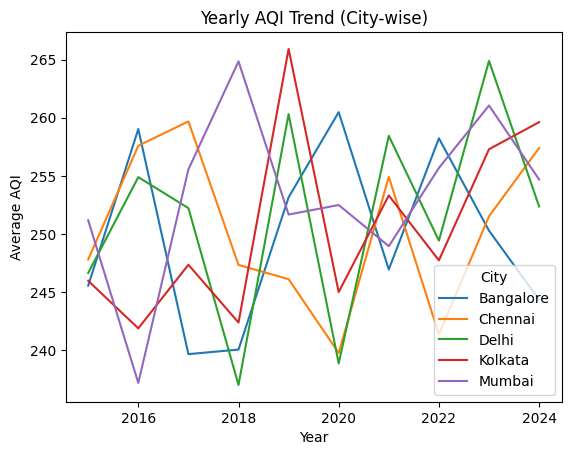

In [ ]:
# Group by BOTH Year and City
yearly_city = df.groupby(['Year', 'City'])['AQI'].mean().reset_index()

sns.lineplot(data=yearly_city, x='Year', y='AQI', hue='City')

plt.title('Yearly AQI Trend (City-wise)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.show()

In [ ]:
# Defining Covid Period

def covid_phase(date):
    if date < pd.Timestamp('2020-03-25'):
        return 'Pre-COVID'
    elif date <= pd.Timestamp('2020-05-31'):
        return 'Lockdown'
    else:
        return 'Post-Lockdown'

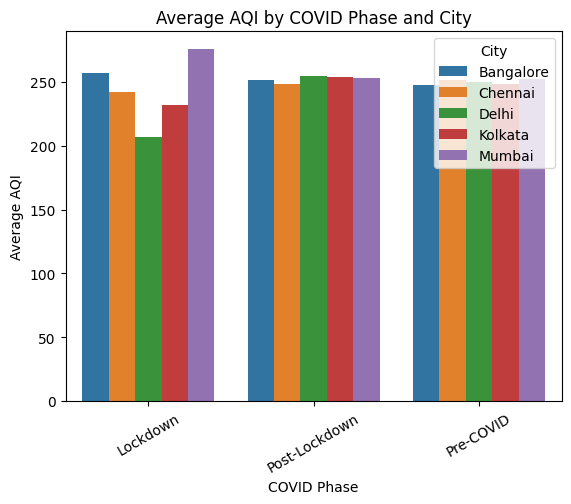

In [ ]:

# Creating dataframe for Covid Period
df['COVID_Phase'] = df['Datetime'].apply(covid_phase)
df.groupby('COVID_Phase')['AQI'].mean()

#  Group by BOTH COVID_Phase and City
covid_city = df.groupby(['COVID_Phase', 'City'])['AQI'].mean().reset_index()


sns.barplot(data=covid_city, x='COVID_Phase', y='AQI', hue='City')
plt.title('Average AQI by COVID Phase and City')
plt.xlabel('COVID Phase')
plt.ylabel('Average AQI')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df.groupby(['City','COVID_Phase'])['AQI'].mean().unstack()

COVID_Phase,Lockdown,Post-Lockdown,Pre-COVID
City,,,
Bangalore,257.144118,251.739761,247.775079
Chennai,242.025000,248.853194,251.937539
Delhi,207.211765,255.029433,249.974503
Kolkata,232.230882,253.631045,248.663560
Mumbai,275.902941,253.387821,252.454712


<Axes: xlabel='Datetime', ylabel='AQI_Smooth'>

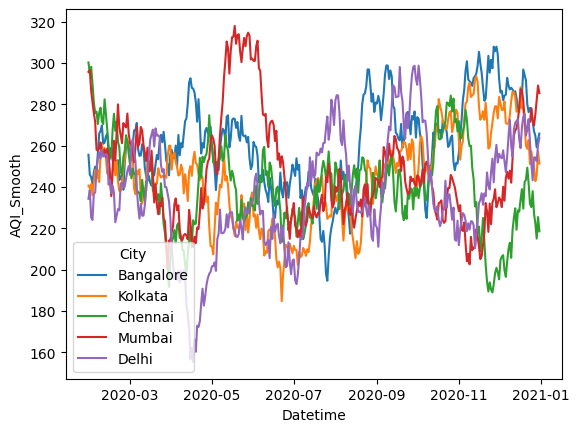

In [ ]:
# Taking moving average to visualize the trend

# Defining dataframe for the lockdown period
df2020 = df.loc[(df['Datetime'] >= '2020-01-01') & (df['Datetime'] <= '2020-12-31')].copy()

# Apply 30-day moving average
df2020['AQI_Smooth'] = df2020.groupby('City')['AQI'].transform(lambda x: x.rolling(30).mean())

sns.lineplot(x='Datetime', y='AQI_Smooth', hue='City', data=df2020)

<Axes: xlabel='COVID_Phase', ylabel='AQI'>

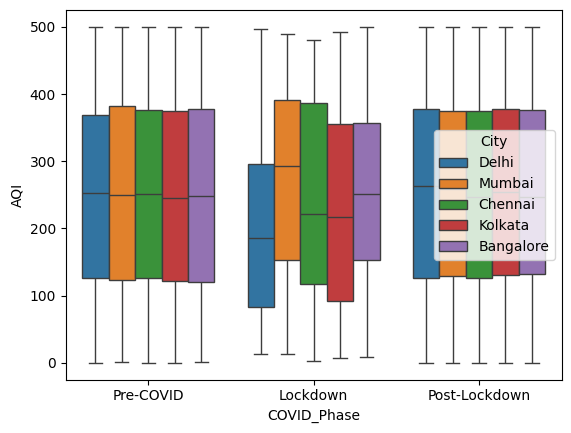

In [ ]:
sns.boxplot(x='COVID_Phase', y='AQI', hue='City', data=df)

In [ ]:
# Make sure pandas shows all columns in one line
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

threshold = 0.3  # strong correlation threshold

for city in cities:
    city_df = df[df['City'] == city]

    # Compute correlation matrix
    corr_matrix = city_df[pollutants].corr()

    print("\n" + "="*70)
    print(f" CORRELATION MATRIX FOR CITY: {city.upper()}")
    print("="*70)
    print(corr_matrix.round(3))

    # Find strong correlations
    strong_corrs = []
    for i, col1 in enumerate(corr_matrix.columns):
        for j, col2 in enumerate(corr_matrix.columns):
            if j > i:  # upper triangle only to avoid duplicates
                corr_value = corr_matrix.loc[col1, col2]
                if abs(corr_value) > threshold:
                    strong_corrs.append((col1, col2, corr_value))

    if strong_corrs:
        print("\nStrong correlations (|r| > 0.3):")
        for col1, col2, val in strong_corrs:
            print(f"{col1} ↔ {col2} : {val:.3f}")
    else:
        print("\nNo strong correlations found.")


 CORRELATION MATRIX FOR CITY: DELHI
         PM2.5   PM10     NO    NO2    NOx    NH3     CO    SO2     O3  Benzene  Toluene  Xylene
PM2.5    1.000 -0.027 -0.026 -0.009 -0.014  0.021 -0.004 -0.024 -0.007   -0.027   -0.018  -0.020
PM10    -0.027  1.000  0.001  0.003  0.003 -0.040 -0.025  0.008 -0.003    0.003   -0.004   0.006
NO      -0.026  0.001  1.000 -0.021  0.006 -0.008  0.010  0.002 -0.007    0.021    0.013   0.029
NO2     -0.009  0.003 -0.021  1.000  0.006 -0.015  0.021 -0.008  0.009    0.002   -0.011  -0.005
NOx     -0.014  0.003  0.006  0.006  1.000  0.005  0.012 -0.020 -0.010   -0.030    0.015  -0.028
NH3      0.021 -0.040 -0.008 -0.015  0.005  1.000 -0.004  0.022 -0.004   -0.002    0.005   0.007
CO      -0.004 -0.025  0.010  0.021  0.012 -0.004  1.000 -0.002  0.019   -0.004   -0.002   0.020
SO2     -0.024  0.008  0.002 -0.008 -0.020  0.022 -0.002  1.000  0.011   -0.018    0.005   0.011
O3      -0.007 -0.003 -0.007  0.009 -0.010 -0.004  0.019  0.011  1.000   -0.006    0.015  

In [ ]:
# Shapiro-Wilk test for Normality

from scipy.stats import shapiro

for pollutant in pollutants:
    print(f"\nNormality check for pollutant: {pollutant}")
    for city in df['City'].unique():
        stat, p = shapiro(df[df['City']==city][pollutant])
        result = "Normal" if p > 0.05 else "Not Normal"
        print(f"{city}: p-value={p:.4f} → {result}")


Normality check for pollutant: PM2.5
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: PM10
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: NO
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: NO2
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-value=0.0000 → Not Normal
Kolkata: p-value=0.0000 → Not Normal
Bangalore: p-value=0.0000 → Not Normal

Normality check for pollutant: NOx
Delhi: p-value=0.0000 → Not Normal
Mumbai: p-value=0.0000 → Not Normal
Chennai: p-

In [ ]:
# ------------------------------------------
# POLLUTANT SIGNIFICANCE ACROSS CITIES
# Goal: For each pollutant, check if its levels differ significantly across the 5 cities.
# ------------------------------------------

from scipy import stats
from statsmodels.stats.anova import AnovaRM
import warnings
warnings.filterwarnings("ignore")

# Significance level
alpha = 0.05

# Loop over pollutants
for pollutant in pollutants:
    print("\n" + "="*70)
    print(f"POLLUTANT: {pollutant}")
    print("="*70)

    # Collect results per city
    sig_cities = []  # stores cities where pollutant is significant
    city_stats = []  # store F/H statistics and p-values

    # Loop over cities
    for city in df['City'].unique():
        city_data = df[df['City'] == city][pollutant]

        # Check normality
        p_normal = stats.shapiro(city_data)[1]

        # Check variance (not needed for Kruskal)
        # For demonstration, assume parametric if normal, else non-parametric
        if p_normal > alpha:
            # Parametric ANOVA (one-way across years or seasons if needed)
            # Here we assume just across years
            # You can modify grouping if needed
            # Since only one city data, we check distribution across Year
            year_groups = [city_data[df['Year']==y] for y in df['Year'].unique()]
            try:
                F_stat, p_val = stats.f_oneway(*year_groups)
            except:
                # fallback if group has only one value
                F_stat, p_val = float('nan'), 1.0
            city_stats.append((city, F_stat, p_val))
            if p_val < alpha:
                sig_cities.append(city)
        else:
            # Non-parametric: Kruskal-Wallis across years
            year_groups = [city_data[df['Year']==y] for y in df['Year'].unique()]
            try:
                H_stat, p_val = stats.kruskal(*year_groups)
            except:
                H_stat, p_val = float('nan'), 1.0
            city_stats.append((city, H_stat, p_val))
            if p_val < alpha:
                sig_cities.append(city)

    # Print city-wise F/H statistics and p-values
    for c, stat, p in city_stats:
        stat_name = "F-statistic" if p_normal > alpha else "H-statistic"
        print(f"{c:10s} → {stat_name}: {stat:.3f}, p-value: {p:.4f}")

    # Print overall summary
    if sig_cities:
        print(f"Result: {pollutant} is SIGNIFICANT for cities: {', '.join(sig_cities)}")
    else:
        print(f"Result: {pollutant} is NOT significant for any city")


POLLUTANT: PM2.5
Delhi      → H-statistic: 15.200, p-value: 0.0856
Mumbai     → H-statistic: 10.959, p-value: 0.2785
Chennai    → H-statistic: 6.632, p-value: 0.6754
Kolkata    → H-statistic: 4.436, p-value: 0.8805
Bangalore  → H-statistic: 2.932, p-value: 0.9669
Result: PM2.5 is NOT significant for any city

POLLUTANT: PM10
Delhi      → H-statistic: 6.810, p-value: 0.6569
Mumbai     → H-statistic: 8.284, p-value: 0.5058
Chennai    → H-statistic: 5.045, p-value: 0.8304
Kolkata    → H-statistic: 7.844, p-value: 0.5500
Bangalore  → H-statistic: 5.798, p-value: 0.7600
Result: PM10 is NOT significant for any city

POLLUTANT: NO
Delhi      → H-statistic: 13.124, p-value: 0.1571
Mumbai     → H-statistic: 4.889, p-value: 0.8439
Chennai    → H-statistic: 3.692, p-value: 0.9305
Kolkata    → H-statistic: 3.458, p-value: 0.9434
Bangalore  → H-statistic: 7.046, p-value: 0.6323
Result: NO is NOT significant for any city

POLLUTANT: NO2
Delhi      → H-statistic: 5.894, p-value: 0.7505
Mumbai     → 

In [ ]:
import statsmodels.formula.api as smf

# Dictionary of significant pollutants per city from Kruskal-Wallis
sig_pollutants = {
    'Bangalore': ['NH3'],
    'Chennai': ['CO', 'Toluene'],
    'Mumbai': ['Toluene'],
    # Delhi, Kolkata → no significant pollutants
}

for city, pollutants_list in sig_pollutants.items():
    city_df = df[df['City'] == city]

    formula = "AQI ~ " + " + ".join(pollutants_list)
    lm = smf.ols(formula=formula, data=city_df).fit()

    print(f"\nCity: {city}")
    print(f"Model: AQI ~ {pollutants_list}")
    print(lm.summary())


City: Bangalore
Model: AQI ~ ['NH3']
                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7080
Date:                Wed, 01 Apr 2026   Prob (F-statistic):              0.400
Time:                        18:54:21   Log-Likelihood:                -23346.
No. Observations:                3653   AIC:                         4.670e+04
Df Residuals:                    3651   BIC:                         4.671e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    2

In [ ]:
import pandas as pd

# Make sure Datetime is a datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Define Lockdown Phase
def lockdown_phase(date):
    if date < pd.Timestamp('2020-03-25'):   # Before lockdown
        return 'Pre-Lockdown'
    elif date <= pd.Timestamp('2020-05-31'):  # Lockdown period
        return 'Lockdown'
    else:
        return 'Post-Lockdown'

df['LockdownPhase'] = df['Datetime'].apply(lockdown_phase)

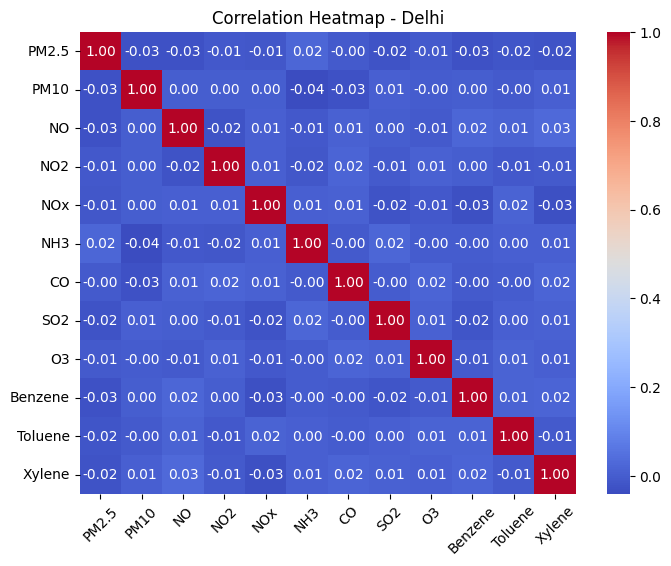

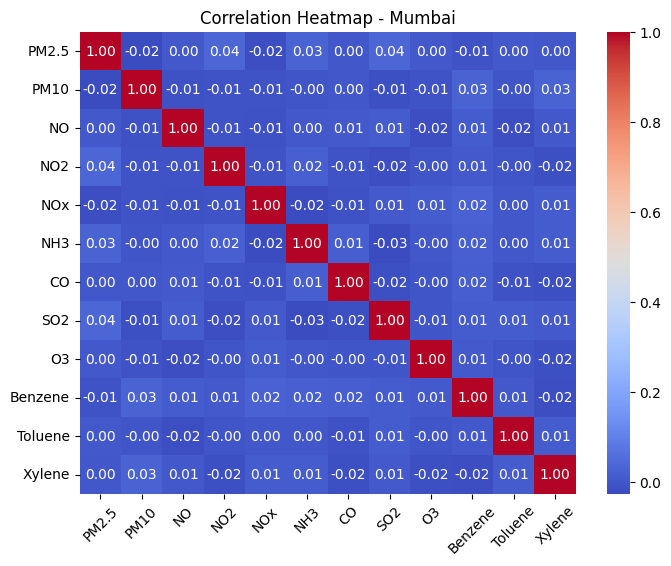

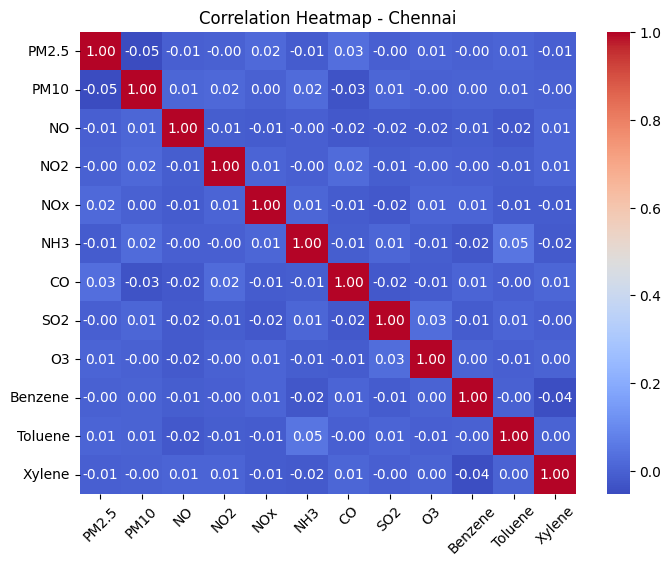

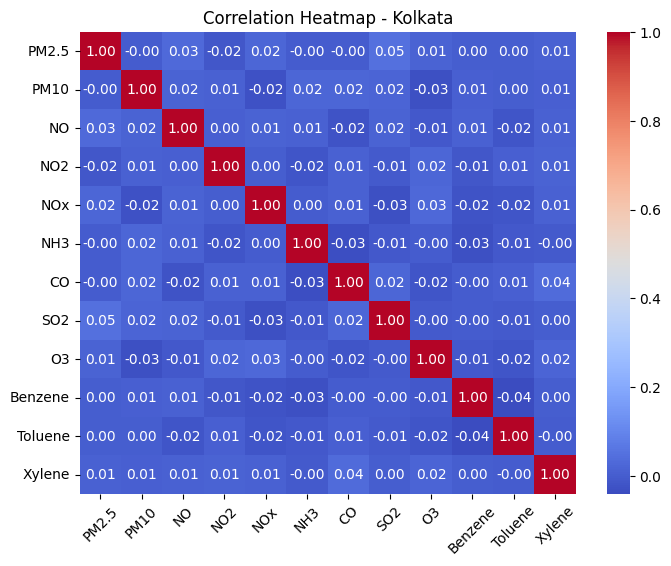

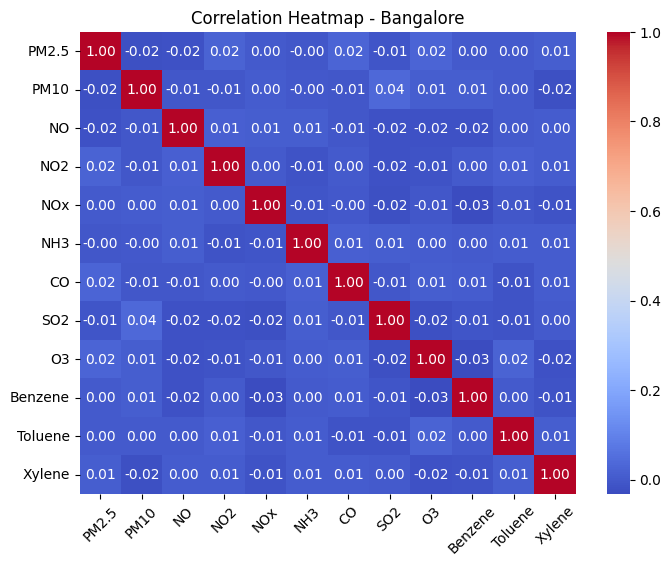

In [ ]:
for city in df['City'].unique():
    plt.figure(figsize=(8,6))
    city_df = df[df['City'] == city]
    corr = city_df[pollutants].corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Heatmap - {city}')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Week'] = df['Datetime'].dt.to_period('W')

weekly_df = df.groupby(['City','Week']).mean(numeric_only=True).reset_index()

In [ ]:
# Loop through each unique city in the weekly aggregated dataset
for city in weekly_df['City'].unique():

    # Print the city name for which correlation is being computed
    print(f"\nWeekly correlation for {city}:\n")

    # Subset the dataset for the current city only
    # This ensures we analyze within-city relationships (important to avoid mixing patterns)
    city_df = weekly_df[weekly_df['City'] == city]

    corr = city_df[pollutants].corr()

    print(corr)


Weekly correlation for Bangalore:

            PM2.5      PM10        NO       NO2       NOx       NH3        CO       SO2        O3   Benzene   Toluene    Xylene
PM2.5    1.000000 -0.019526 -0.091513 -0.023421  0.007964  0.002541  0.068863 -0.064435 -0.002492  0.019435 -0.030080  0.041244
PM10    -0.019526  1.000000  0.006691 -0.062766  0.050747 -0.038604 -0.026775  0.007880  0.001164  0.021796  0.019986  0.037838
NO      -0.091513  0.006691  1.000000  0.022649  0.064371  0.100084 -0.007442 -0.082443  0.000543 -0.022861  0.033894  0.032197
NO2     -0.023421 -0.062766  0.022649  1.000000 -0.050239 -0.004163  0.048133  0.036662  0.013536  0.040459  0.007232  0.068531
NOx      0.007964  0.050747  0.064371 -0.050239  1.000000 -0.055573  0.026675 -0.002575 -0.015062 -0.057174 -0.053838 -0.094800
NH3      0.002541 -0.038604  0.100084 -0.004163 -0.055573  1.000000  0.052683 -0.004035  0.030206 -0.008902 -0.000415  0.006454
CO       0.068863 -0.026775 -0.007442  0.048133  0.026675  0.052683 

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
weekly_df[pollutants] = scaler.fit_transform(weekly_df[pollutants])

In [ ]:
# Import required libraries
import pandas as pd

# Convert 'Datetime' column to proper datetime format
# WHY: Ensures we can extract time-based features like week, month, etc.
df['Datetime'] = pd.to_datetime(df['Datetime'])


# Create a 'Week' variable using pandas Period
# WHAT: Converts each date into its corresponding week
# WHY: Daily data is very noisy; weekly aggregation smooths fluctuations and reveals trends
df['Week'] = df['Datetime'].dt.to_period('W')


# Aggregate data at City + Week level
# WHAT: Taking mean of AQI and all pollutants for each city-week combination
# WHY: This reduces random day-to-day noise and gives a stable representation of pollution levels
weekly_df = df.groupby(['City', 'Week']).mean(numeric_only=True).reset_index()


# Check first few rows to confirm transformation
# WHY: Always verify data after transformation to avoid silent errors
print(weekly_df.head())

        City                   Week       PM2.5        PM10          NO  \
0  Bangalore  2014-12-29/2015-01-04  129.875000  200.200000  150.700000   
1  Bangalore  2015-01-05/2015-01-11  318.028571  373.085714   71.900000   
2  Bangalore  2015-01-12/2015-01-18  252.700000  290.557143  111.042857   
3  Bangalore  2015-01-19/2015-01-25  262.157143  187.557143   84.800000   
4  Bangalore  2015-01-26/2015-02-01  291.400000  208.357143   83.271429   

         NO2         NOx        NH3        CO        SO2          O3  \
0  82.050000  119.625000  43.150000  3.792500  52.825000  110.650000   
1  61.157143   80.942857  26.057143  4.888571  59.557143   95.142857   
2  82.657143  198.828571  14.928571  5.764286  41.228571   68.728571   
3  88.171429  106.757143  19.171429  5.172857  46.228571  135.285714   
4  89.114286  118.228571  23.685714  5.274286  48.700000   83.285714   

     Benzene    Toluene    Xylene         AQI  
0  12.180000  11.577500  8.395000  326.200000  
1  10.507143  19.498

In [ ]:
# -------------------------------
# STEP 2A: Convert Week to timestamp
# -------------------------------

# Convert 'Week' (which is currently a period) back to a timestamp
# WHAT: Changes weekly period into an actual date (start of the week)
# WHY: Needed because regression models work better with numeric or datetime formats
weekly_df['Week_start'] = weekly_df['Week'].dt.start_time


# -------------------------------
# STEP 2B: Create a Time index
# -------------------------------

# Sort data by City and Week to maintain chronological order
# WHY: Time index must follow correct sequence for each city
weekly_df = weekly_df.sort_values(['City', 'Week_start'])

# Create a time variable (running index within each city)
# WHAT: Assigns 1, 2, 3, ... for each week per city
# WHY: Captures long-term trend (increase/decrease in AQI over time)
weekly_df['Time'] = weekly_df.groupby('City').cumcount() + 1


# -------------------------------
# STEP 2C: Create Lockdown variable
# -------------------------------

# Define lockdown period (India lockdown: 25 March 2020 – 31 May 2020)
# WHAT: Create a binary variable (0 = no lockdown, 1 = lockdown period)
# WHY: This is your main variable of interest (to measure lockdown effect)
weekly_df['Lockdown'] = ((weekly_df['Week_start'] >= '2020-03-25') &
                         (weekly_df['Week_start'] <= '2020-05-31')).astype(int)


# -------------------------------
# STEP 2D: (Optional but recommended) Post-lockdown variable
# -------------------------------

# WHAT: Indicator for post-lockdown period
# WHY: Helps capture recovery or rebound effect after lockdown ends
weekly_df['PostLockdown'] = (weekly_df['Week_start'] > '2020-05-31').astype(int)


# -------------------------------
# STEP 2E: Quick check
# -------------------------------

# Display a few rows to verify variables
# WHY: Ensures that Time and Lockdown variables are correctly created
weekly_df[['City', 'Week_start', 'Time', 'Lockdown', 'PostLockdown']]

,City,Week_start,Time,Lockdown,PostLockdown
0,Bangalore,2014-12-29,1,0,0
1,Bangalore,2015-01-05,2,0,0
2,Bangalore,2015-01-12,3,0,0
3,Bangalore,2015-01-19,4,0,0
4,Bangalore,2015-01-26,5,0,0
...,...,...,...,...,...
2610,Mumbai,2024-12-02,519,0,1
2611,Mumbai,2024-12-09,520,0,1
2612,Mumbai,2024-12-16,521,0,1
2613,Mumbai,2024-12-23,522,0,1


In [ ]:
# Import required libraries for regression
import statsmodels.api as sm
import statsmodels.formula.api as smf


# -------------------------------
# STEP 3A: Fit baseline regression model
# -------------------------------

# WHAT: We are fitting a linear regression model using statsmodels
# WHY: This model helps us estimate the effect of Lockdown on AQI,
#      while controlling for time trend and city-specific differences

# Model specification:
# AQI ~ Lockdown + Time + C(City)
# - AQI = dependent variable
# - Lockdown = main variable of interest
# - Time = controls long-term trend
# - C(City) = treats City as categorical (fixed effects)

model_baseline = smf.ols(
    formula='AQI ~ Lockdown + Time + C(City)',
    data=weekly_df
).fit()

print(model_baseline.summary())

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8504
Date:                Wed, 01 Apr 2026   Prob (F-statistic):              0.531
Time:                        12:22:21   Log-Likelihood:                -14184.
No. Observations:                2615   AIC:                         2.838e+04
Df Residuals:                    2608   BIC:                         2.842e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            246.4767      3

In [ ]:
# Import required function for quoting column names
from patsy import dmatrices, ModelDesc, Term, EvalFactor


# Convert pollutant names into safe format
# Q("PM2.5") instead of PM2.5
# Prevent syntax errors in regression formula
pollutants_quoted = [f'Q("{p}")' for p in pollutants]


# Build formula safely
# Combine all variables into regression formula
# This ensures model runs without syntax errors
formula = 'AQI ~ Lockdown + Time + C(City) + ' + ' + '.join(pollutants_quoted)


# Fit model
# Running corrected regression model
# Now statsmodels can correctly interpret all variables
model_full = smf.ols(formula=formula, data=weekly_df).fit()


print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.042
Date:                Wed, 01 Apr 2026   Prob (F-statistic):              0.408
Time:                        17:41:58   Log-Likelihood:                -14177.
No. Observations:                2615   AIC:                         2.839e+04
Df Residuals:                    2596   BIC:                         2.850e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            229.9481     17

In [ ]:
# Check correlation between AQI and PM2.5 (daily data)

print(df[['AQI', 'PM2.5']].corr())

            AQI     PM2.5
AQI    1.000000  0.000655
PM2.5  0.000655  1.000000


In [ ]:
# Regress PM2.5 on lockdown, time, and city
# To measure how lockdown impacted pollution levels directly

model_pm25 = smf.ols(
    formula='Q("PM2.5") ~ Lockdown + Time + C(City)',
    data=weekly_df
).fit()

# Print results
print(model_pm25.summary())

                            OLS Regression Results                            
Dep. Variable:             Q("PM2.5")   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.5917
Date:                Wed, 01 Apr 2026   Prob (F-statistic):              0.737
Time:                        12:29:33   Log-Likelihood:                -14200.
No. Observations:                2615   AIC:                         2.841e+04
Df Residuals:                    2608   BIC:                         2.846e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            248.1577      3

In [ ]:
# Check summary statistics city-wise

print(df.groupby('City')[['AQI', 'PM2.5']].mean())

# Pollution should vary over time

print(df[['AQI', 'PM2.5']].describe())

# Look for obvious inconsistencies
print(df[['City', 'Datetime', 'AQI', 'PM2.5']])

                  AQI       PM2.5
City                             
Bangalore  249.767397  248.546838
Chennai    250.338763  252.515138
Delhi      251.496304  252.905858
Kolkata    250.635396  250.456885
Mumbai     253.319053  248.563756
                AQI         PM2.5
count  18265.000000  18265.000000
mean     251.111382    250.597695
std      144.502626    144.460292
min        0.000000      0.000000
25%      125.400000    125.700000
50%      251.200000    251.000000
75%      376.400000    376.200000
max      500.000000    499.900000
            City   Datetime    AQI  PM2.5
0          Delhi 2015-01-01  204.5  153.3
1         Mumbai 2015-01-01   60.9   70.5
2        Chennai 2015-01-01  486.5  174.1
3        Kolkata 2015-01-01  174.4  477.2
4      Bangalore 2015-01-01  489.7  171.6
...          ...        ...    ...    ...
18260    Chennai 2024-12-31  366.1  188.6
18261    Kolkata 2024-12-31  397.5  343.0
18262      Delhi 2024-12-31   61.5  371.2
18263     Mumbai 2024-12-31  312.7  

In [ ]:
df.groupby(df['Datetime'].dt.year)[pollutants].corr()

PM2.5      PM10        NO       NO2       NOx       NH3  \
Datetime                                                                       
2015     PM2.5    1.000000 -0.056434 -0.039830 -0.001855  0.030340  0.010758   
         PM10    -0.056434  1.000000 -0.038044  0.005994 -0.020215  0.047585   
         NO      -0.039830 -0.038044  1.000000 -0.027846  0.013315 -0.030633   
         NO2     -0.001855  0.005994 -0.027846  1.000000 -0.005486 -0.018734   
         NOx      0.030340 -0.020215  0.013315 -0.005486  1.000000 -0.044935   
...                    ...       ...       ...       ...       ...       ...   
2024     SO2      0.019672  0.021643 -0.007969 -0.018625 -0.048568  0.009589   
         O3       0.030077 -0.042133 -0.000122  0.009640  0.010020  0.000438   
         Benzene -0.034844  0.003023  0.006446 -0.009001 -0.009665 -0.022049   
         Toluene  0.018084 -0.007279  0.004067 -0.045412  0.028156 -0.000677   
         Xylene   0.044827  0.008085 -0.002469  0.020723 -0.032544 -0.014740   

                        CO       SO2        O3   Benzene   Toluene    Xylene  
Datetime                                                                      
2015     PM2.5    0.024781 -0.022198  0.036183  0.003155 -0.009047  0.009308  
         PM10    -0.016349  0.029821 -0.006085 -0.015072 -0.000274  0.009039  
         NO       0.002108  0.060729 -0.037714  0.031567 -0.019365  0.008034  
         NO2     -0.018190 -0.031416  0.016235  0.006318 -0.037118  0.023193  
         NOx     -0.013838 -0.002274 -0.044219 -0.029658 -0.020245 -0.034683  
...                    ...       ...       ...       ...       ...       ...  
2024     SO2     -0.012174  1.000000  0.009756 -0.029241 -0.009628  0.021594  
         O3       0.014421  0.009756  1.000000 -0.047502  0.014835 -0.026606  
         Benzene -0.001132 -0.029241 -0.047502  1.000000 -0.012530 -0.014873  
         Toluene -0.001722 -0.009628  0.014835 -0.012530  1.000000 -0.002767  
         Xylene   0.025899  0.021594 -0.026606 -0.014873 -0.002767  1.000000  

[120 rows x 12 columns]

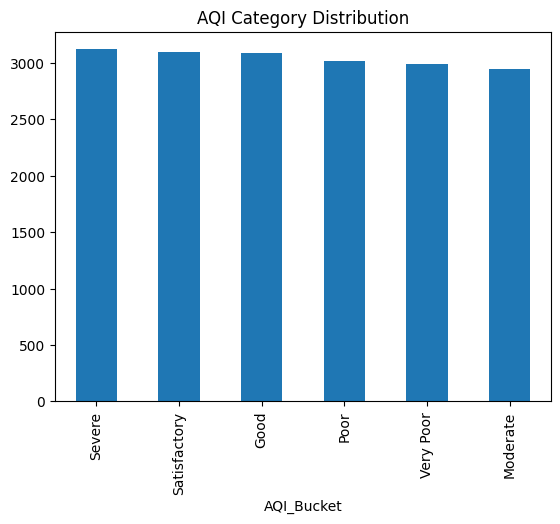

In [ ]:
df['AQI_Bucket'].value_counts().plot(kind='bar')
plt.title("AQI Category Distribution")
plt.show()

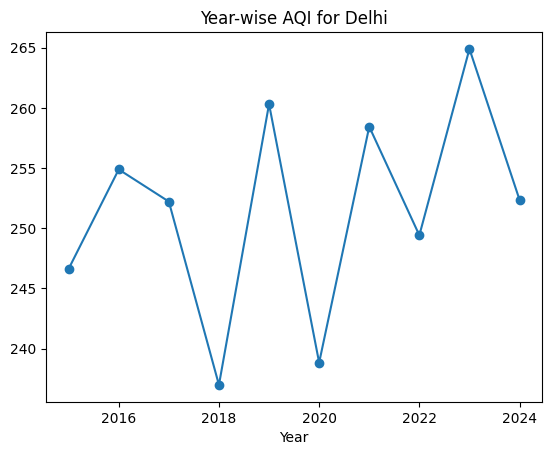

In [ ]:
city_year_aqi = city_df.groupby('Year')['AQI'].mean()

city_year_aqi.plot(marker='o')
plt.title("Year-wise AQI for Delhi")
plt.show()

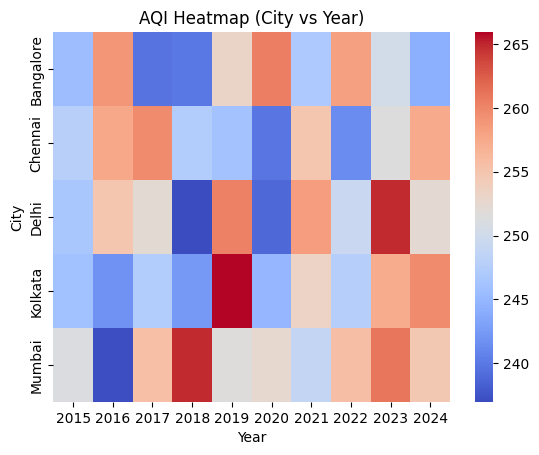

In [ ]:
pivot = df.pivot_table(values='AQI', index='City', columns='Year', aggfunc='mean')

sns.heatmap(pivot, cmap='coolwarm')
plt.title("AQI Heatmap (City vs Year)")
plt.show()

In [ ]:
# -------------------------------
# Convert datetime properly
# -------------------------------
df['Date'] = pd.to_datetime(df['Datetime'])   # use your correct column name

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# -------------------------------
# CLEAN COLUMN NAMES
# -------------------------------
# Remove spaces and special characters
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace(r'[^\w]', '', regex=True)

# Print to verify pollutant names
print("Columns after cleaning:")
print(df.columns)

# -------------------------------
# MONTHLY AGGREGATION (KEEP ALL POLLUTANTS)
# -------------------------------
monthly_df = df.groupby(['City', 'Year', 'Month']).agg({
    'AQI': 'mean',
    'PM25': 'mean',     # adjust if your column is PM2_5
    'PM10': 'mean',
    'NO': 'mean',
    'NO2': 'mean',
    'NOx': 'mean',
    'NH3': 'mean',
    'CO': 'mean',
    'SO2': 'mean',
    'O3': 'mean',
    'Benzene': 'mean',
    'Toluene': 'mean',
    'Xylene': 'mean'

}).reset_index()

# -------------------------------
# RENAME FOR CONSISTENCY (OPTIONAL BUT RECOMMENDED)
# -------------------------------
monthly_df = monthly_df.rename(columns={
    'PM25': 'PM2_5'
})

# -------------------------------
# CREATE TIME FEATURES
# -------------------------------
# Create proper datetime column
monthly_df['MonthStart'] = pd.to_datetime(monthly_df[['Year', 'Month']].assign(DAY=1))

# Sort properly
monthly_df = monthly_df.sort_values(['City', 'Year', 'Month'])

# Time index (trend)
monthly_df['TimeIndex'] = monthly_df.groupby('City').cumcount()

# Month as categorical (for seasonality)
monthly_df['Month'] = monthly_df['Month'].astype('category')

# -------------------------------
# OPTIONAL 3-MONTH ROLLING AVERAGE
# -------------------------------
monthly_df['AQI_3month_avg'] = monthly_df.groupby('City')['AQI'] \
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# -------------------------------
# FINAL CHECK
# -------------------------------
print("\nFinal columns in monthly_df:")
print(monthly_df.columns)

# View full dataframe
monthly_df

Columns after cleaning:
Index(['Datetime', 'City', 'PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Season', 'Year', 'COVID_Phase', 'Date', 'Month'], dtype='object')

Final columns in monthly_df:
Index(['City', 'Year', 'Month', 'AQI', 'PM2_5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'MonthStart', 'TimeIndex', 'AQI_3month_avg'], dtype='object')


,City,Year,Month,AQI,PM2_5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,MonthStart,TimeIndex,AQI_3month_avg
0,Bangalore,2015,1,249.022581,262.706452,252.251613,96.322581,80.154839,122.548387,23.012903,5.194516,49.106452,100.432258,9.212581,16.816452,5.738065,2015-01-01,0,249.022581
1,Bangalore,2015,2,236.503571,274.125000,308.335714,96.071429,77.421429,118.846429,24.246429,4.396786,48.857143,86.364286,11.120714,16.316786,4.495000,2015-02-01,1,242.763076
2,Bangalore,2015,3,246.629032,215.974194,337.148387,93.380645,80.577419,124.506452,24.670968,5.093548,44.906452,107.441935,11.890323,14.126452,3.838710,2015-03-01,2,244.051728
3,Bangalore,2015,4,246.720000,246.700000,298.303333,103.633333,72.280000,139.880000,23.893333,5.499333,46.293333,88.136667,7.796667,19.699667,5.185333,2015-04-01,3,243.284201
4,Bangalore,2015,5,249.077419,259.232258,330.112903,90.425806,90.754839,129.258065,32.548387,4.187419,47.167742,102.706452,9.591290,14.829677,5.539355,2015-05-01,4,247.475484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,Mumbai,2024,8,278.348387,231.912903,340.193548,88.648387,72.725806,130.206452,24.609677,5.204194,49.045161,111.090323,9.418710,11.428710,5.400645,2024-08-01,115,244.449821
596,Mumbai,2024,9,275.503333,231.646667,302.813333,98.766667,81.863333,122.420000,24.430000,4.922000,47.840000,95.756667,8.266667,16.356000,4.843333,2024-09-01,116,260.906487
597,Mumbai,2024,10,226.909677,262.822581,332.164516,110.035484,59.890323,121.041935,23.232258,4.509032,50.796774,104.625806,10.636774,15.198710,4.629677,2024-10-01,117,260.253799
598,Mumbai,2024,11,228.620000,212.790000,269.873333,89.990000,81.636667,130.856667,25.006667,3.974333,52.396667,96.440000,10.781667,14.885667,4.267000,2024-11-01,118,243.677670


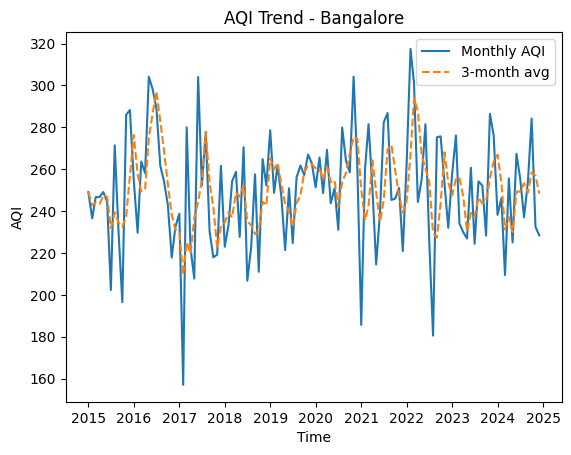

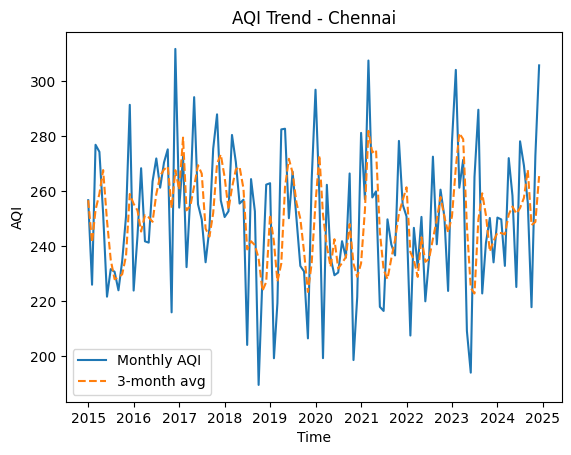

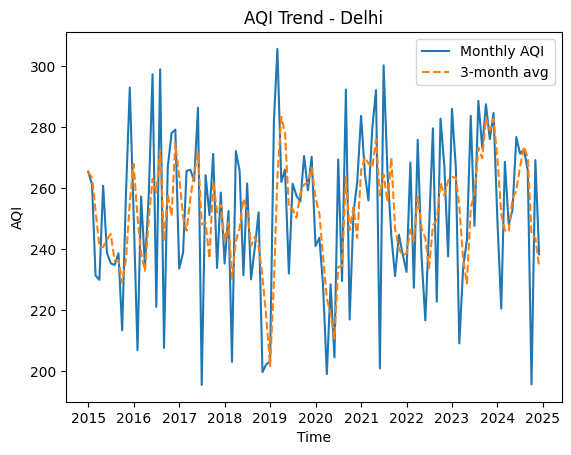

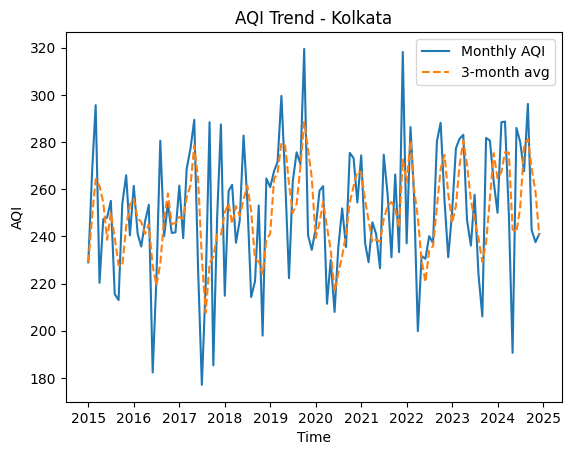

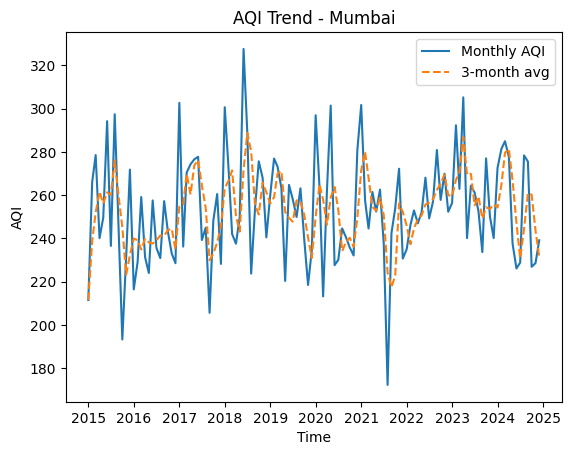

In [ ]:
for city in monthly_df['City'].unique():
    city_df = monthly_df[monthly_df['City'] == city]

    plt.figure()
    plt.plot(city_df['MonthStart'], city_df['AQI'], label='Monthly AQI')
    plt.plot(city_df['MonthStart'], city_df['AQI_3month_avg'], linestyle='--', label='3-month avg')

    plt.title(f"AQI Trend - {city}")
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.legend()
    plt.show()

In [ ]:
import statsmodels.formula.api as smf

# Time index (trend)
monthly_df = monthly_df.sort_values(['City', 'Year', 'Month'])
monthly_df['TimeIndex'] = monthly_df.groupby('City').cumcount()

# Month as categorical
monthly_df['Month'] = monthly_df['Month'].astype('category')